In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("student_performance_multi.csv")
df.sample(10)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
2538,8,97,Yes,5,7,90.0
1282,3,84,No,4,6,62.0
6444,9,41,Yes,4,4,36.0
9139,9,59,Yes,9,8,57.0
2940,9,90,No,8,6,88.0
2976,2,43,Yes,7,7,18.0
9073,8,97,No,8,1,91.0
446,9,98,No,6,7,96.0
5956,1,94,Yes,8,4,66.0
1626,5,84,No,5,3,66.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [17]:
df.isna().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

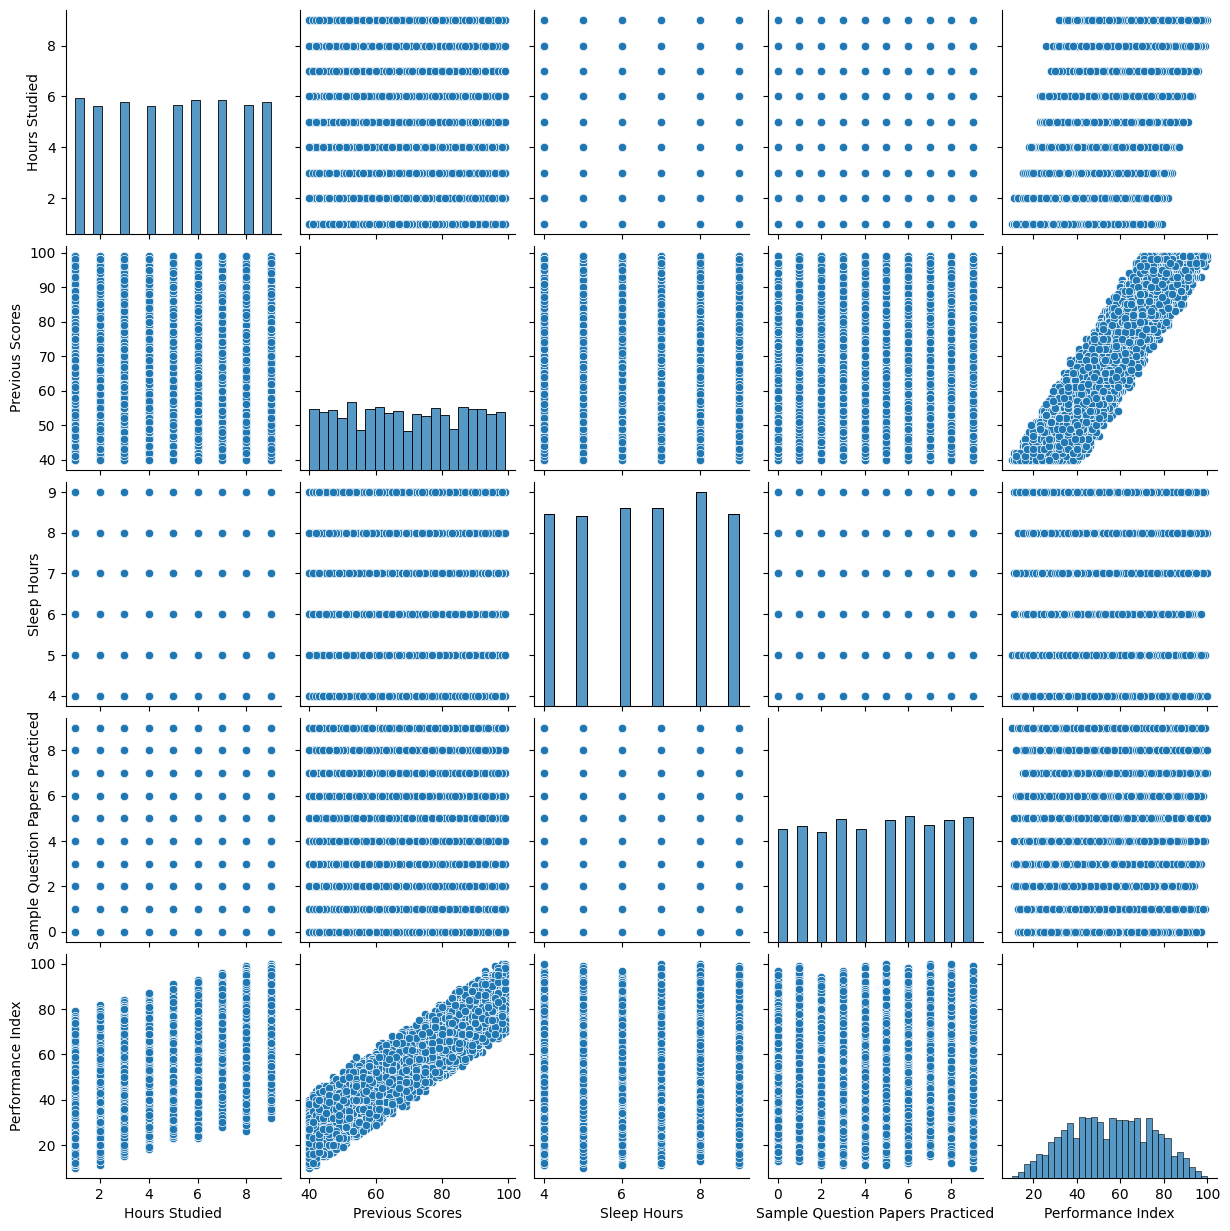

In [4]:
sns.pairplot(df)

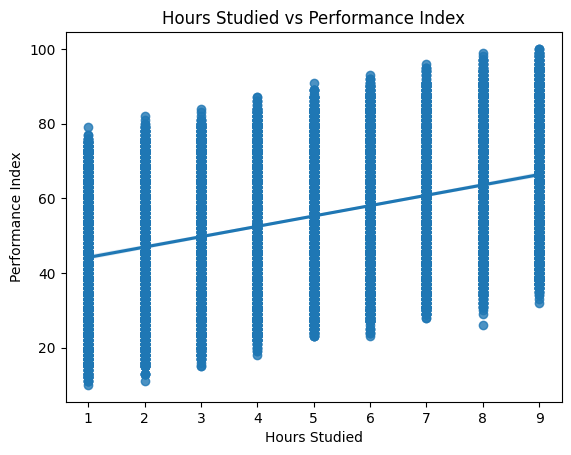

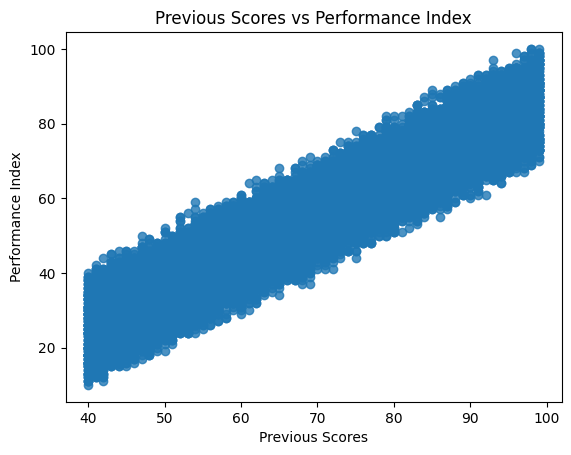

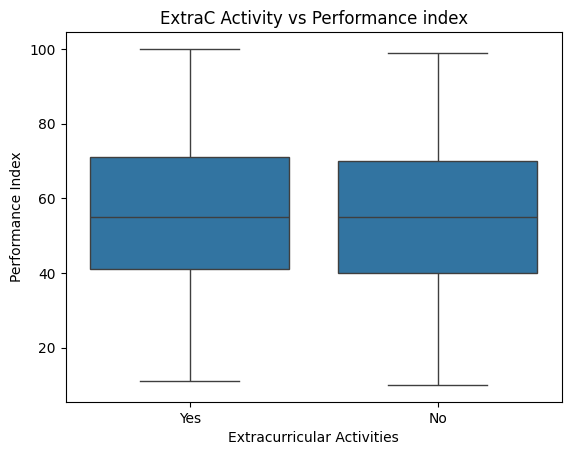

In [5]:
#From above I can say their is strong relation between performance index and previos scores ,perfornace index and hours studied
sns.regplot(x="Hours Studied", y="Performance Index", data=df)
plt.title("Hours Studied vs Performance Index")
plt.show()

sns.regplot(x="Previous Scores", y="Performance Index", data=df)
plt.title("Previous Scores vs Performance Index")
plt.show()

sns.boxplot(
    x="Extracurricular Activities",
    y="Performance Index",
    data=df
)
plt.title("ExtraC Activity vs Performance index")
plt.show()

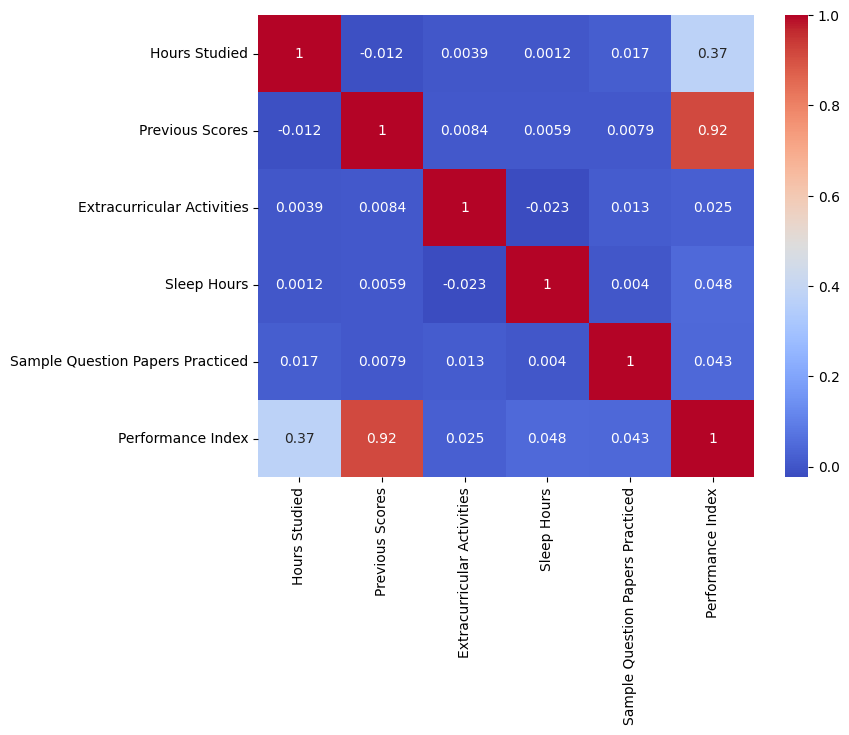

In [6]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({
    "Yes":1,
    "No":0
})

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [7]:
#As we are getting very weired solution -the problem might be gradient descet works between when normalize,as differt scale make gradient desent ineffective
X1 = df["Hours Studied"].values
X2 = df["Previous Scores"].values
Y = df["Performance Index"].values
x1 = ((X1-(X1.mean()))/X1.std())
x2 = ((X2-(X2.mean()))/X2.std())
y = ((Y-(Y.mean()))/Y.std())

In [8]:
#the highly coorelated features are:Hours study,previous score so we will use this two feature to make model
threshod = 0.01
m1,m2,c=0,0,0
lr=0.01
for i in range(50):
    y_pred = m1*x1 +m2*x2 +c
    cost = np.mean((y_pred-y)**2)
    # print(cost)
    if(cost<threshod):
        break
    dJ_dm1 = np.mean(2*(y_pred-y)*x1)
    dJ_dm2 = np.mean(2*(y_pred-y)*x2)
    dJ_dc = np.mean(2*(y_pred-y))
    m1 = m1-lr*dJ_dm1
    m2 = m2-lr*dJ_dm2
    c = c-lr*dJ_dc
y_pred = m1*x1 +m2*x2 +c
cost = np.mean((y_pred-y)**2)
print("m1 is:" ,m1)
print("m2 is:" ,m2)
print("c is:",c)
# print(cost)

m1 is: 0.24062973773683521
m2 is: 0.5831395427549356
c is: -4.595790414896328e-17


In [9]:
#From above I can say their is strong relation between performance index and previos scores ,perfornace index and hours studied
print(type(x1))
print(type(x2))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


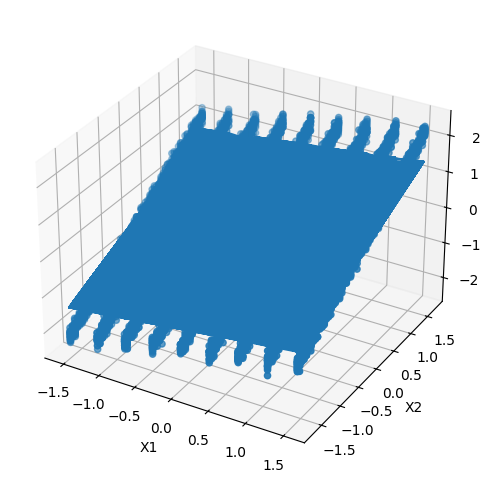

In [15]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1, x2, y)
ax.plot(x1, x2, y_pred)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")

plt.show()